## Business Understanding
The dataset was collected during 60 days, this is a real database of a brazilian logistics company.

The database was collected during 60 days, this is a real database of a Brazilian company of large logistics. Twelve predictive attributes and a target that is the total of orders for daily. treatment

In [151]:
import matplotlib.pyplot  as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn import tree 
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, roc_auc_score

In [152]:
demand_df=pd.read_csv("data/Daily_Demand_Forecasting_Orders.csv", sep=';')

In [153]:
demand_df.head()

,"Week of the month (first week, second, third, fourth or fifth week",Day of the week (Monday to Friday),Non-urgent order,Urgent order,Order type A,Order type B,Order type C,Fiscal sector orders,Orders from the traffic controller sector,Banking orders (1),Banking orders (2),Banking orders (3),Target (Total orders)
0,1,4,316.307,223.270,61.543,175.586,302.448,0.000,65556,44914,188411,14793,539.577
1,1,5,128.633,96.042,38.058,56.037,130.580,0.000,40419,21399,89461,7679,224.675
2,1,6,43.651,84.375,21.826,25.125,82.461,1.386,11992,3452,21305,14947,129.412
3,2,2,171.297,127.667,41.542,113.294,162.284,18.156,49971,33703,69054,18423,317.120
4,2,3,90.532,113.526,37.679,56.618,116.220,6.459,48534,19646,16411,20257,210.517


In [154]:
demand_df.tail()

,"Week of the month (first week, second, third, fourth or fifth week",Day of the week (Monday to Friday),Non-urgent order,Urgent order,Order type A,Order type B,Order type C,Fiscal sector orders,Orders from the traffic controller sector,Banking orders (1),Banking orders (2),Banking orders (3),Target (Total orders)
55,5,2,158.716,158.133,59.131,92.639,165.079,0.000,32027,33282,128269,9287,316.849
56,5,3,150.784,133.069,54.224,115.746,116.442,2.559,51235,34421,87708,11354,286.412
57,5,4,193.534,109.639,58.378,142.382,102.687,274.000,28364,88404,91367,15003,303.447
58,5,5,196.555,108.395,76.763,96.478,131.709,0.000,37011,109931,50112,12957,304.950
59,5,6,192.116,121.106,107.568,121.152,103.180,18.678,27328,108072,56015,10690,331.900


In [155]:
demand_df.columns

Index(['Week of the month (first week, second, third, fourth or fifth week',
       'Day of the week (Monday to Friday)', 'Non-urgent order',
       'Urgent order', 'Order type A', 'Order type B', 'Order type C',
       'Fiscal sector orders', 'Orders from the traffic controller sector',
       'Banking orders (1)', 'Banking orders (2)', 'Banking orders (3)',
       'Target (Total orders)'],
      dtype='str')

Target variable is:Target (Total orders)

In [156]:
features = ['Week of the month (first week, second, third, fourth or fifth week',
       'Day of the week (Monday to Friday)', 'Non-urgent order',
       'Urgent order', 'Order type A', 'Order type B', 'Order type C',
       'Fiscal sector orders', 'Orders from the traffic controller sector',
       'Banking orders (1)', 'Banking orders (2)', 'Banking orders (3)',
       'Target (Total orders)']
X = demand_df[features]

In [157]:
demand_df.isnull().sum()

Week of the month (first week, second, third, fourth or fifth week    0
Day of the week (Monday to Friday)                                    0
Non-urgent order                                                      0
Urgent order                                                          0
Order type A                                                          0
Order type B                                                          0
Order type C                                                          0
Fiscal sector orders                                                  0
Orders from the traffic controller sector                             0
Banking orders (1)                                                    0
Banking orders (2)                                                    0
Banking orders (3)                                                    0
Target (Total orders)                                                 0
dtype: int64

In [158]:
def checkCategories(demand_df, column):
    display(demand_df[column].unique())

In [159]:
X = demand_df[features]
X.head()

,"Week of the month (first week, second, third, fourth or fifth week",Day of the week (Monday to Friday),Non-urgent order,Urgent order,Order type A,Order type B,Order type C,Fiscal sector orders,Orders from the traffic controller sector,Banking orders (1),Banking orders (2),Banking orders (3),Target (Total orders)
0,1,4,316.307,223.270,61.543,175.586,302.448,0.000,65556,44914,188411,14793,539.577
1,1,5,128.633,96.042,38.058,56.037,130.580,0.000,40419,21399,89461,7679,224.675
2,1,6,43.651,84.375,21.826,25.125,82.461,1.386,11992,3452,21305,14947,129.412
3,2,2,171.297,127.667,41.542,113.294,162.284,18.156,49971,33703,69054,18423,317.120
4,2,3,90.532,113.526,37.679,56.618,116.220,6.459,48534,19646,16411,20257,210.517


In [160]:
y = demand_df['Target (Total orders)']
y.head()

0    539.577
1    224.675
2    129.412
3    317.120
4    210.517
Name: Target (Total orders), dtype: float64

Train-Test Split

In [161]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [162]:
X = demand_df.drop('Target (Total orders)', axis=1)
y = demand_df['Target (Total orders)']

Train a Regression Model- Since the target is continuous numeric data, use regression.

In [163]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


prediction

In [164]:
y_pred = model.predict(X_test)

evaluate

In [165]:
corr = demand_df.corr(numeric_only=True)

print(corr['Target (Total orders)'].sort_values(ascending=False))

Target (Total orders)                                                 1.000000
Non-urgent order                                                      0.934518
Order type B                                                          0.900673
Order type C                                                          0.804984
Banking orders (2)                                                    0.798447
Urgent order                                                          0.729785
Banking orders (1)                                                    0.630365
Order type A                                                          0.559735
Orders from the traffic controller sector                             0.244712
Week of the month (first week, second, third, fourth or fifth week    0.211709
Banking orders (3)                                                    0.100901
Fiscal sector orders                                                 -0.052116
Day of the week (Monday to Friday)                  

evaluate

In [166]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Features and target
X = demand_df.drop('Target (Total orders)', axis=1)
y =demand_df['Target (Total orders)']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Create model
tree_model = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

# Train model
tree_model.fit(X_train, y_train)

# Predictions
y_pred = tree_model.predict(X_test)

# Evaluation
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 61.88042361111112
RMSE: 81.99758607702371
R2 Score: 0.3431024797375585


feature importance - decision tree

In [167]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': tree_model.feature_importances_
})

print(
    importance_df.sort_values(
        by='Importance',
        ascending=False
    )
)

                                              Feature  Importance
6                                        Order type C    0.690200
5                                        Order type B    0.173697
11                                 Banking orders (3)    0.094555
4                                        Order type A    0.026938
1                  Day of the week (Monday to Friday)    0.009183
2                                    Non-urgent order    0.004833
7                                Fiscal sector orders    0.000549
8           Orders from the traffic controller sector    0.000044
3                                        Urgent order    0.000000
0   Week of the month (first week, second, third, ...    0.000000
9                                  Banking orders (1)    0.000000
10                                 Banking orders (2)    0.000000


visualization

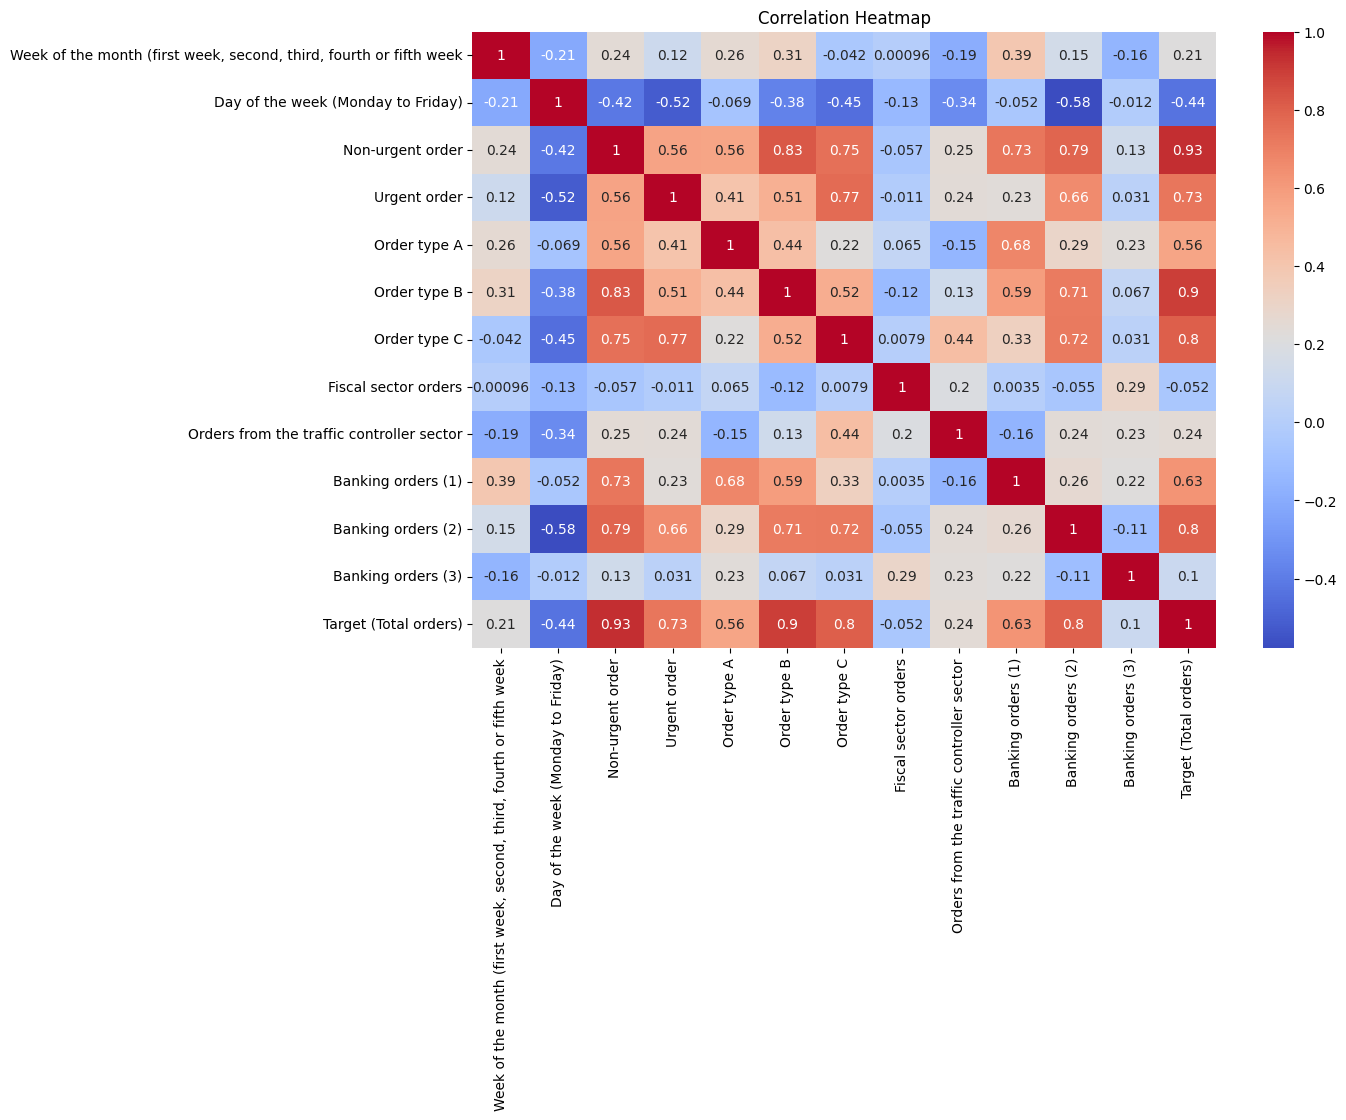

In [168]:
plt.figure(figsize=(12,8))

sns.heatmap(
    demand_df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

In [169]:

print(r2_score(y_test, y_pred))

0.3431024797375585


In [170]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.6876590508090403


In [173]:
tree_model = DecisionTreeRegressor(
    max_depth=1,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred = tree_model.predict(X_test)

In [175]:
X.shape

(60, 12)

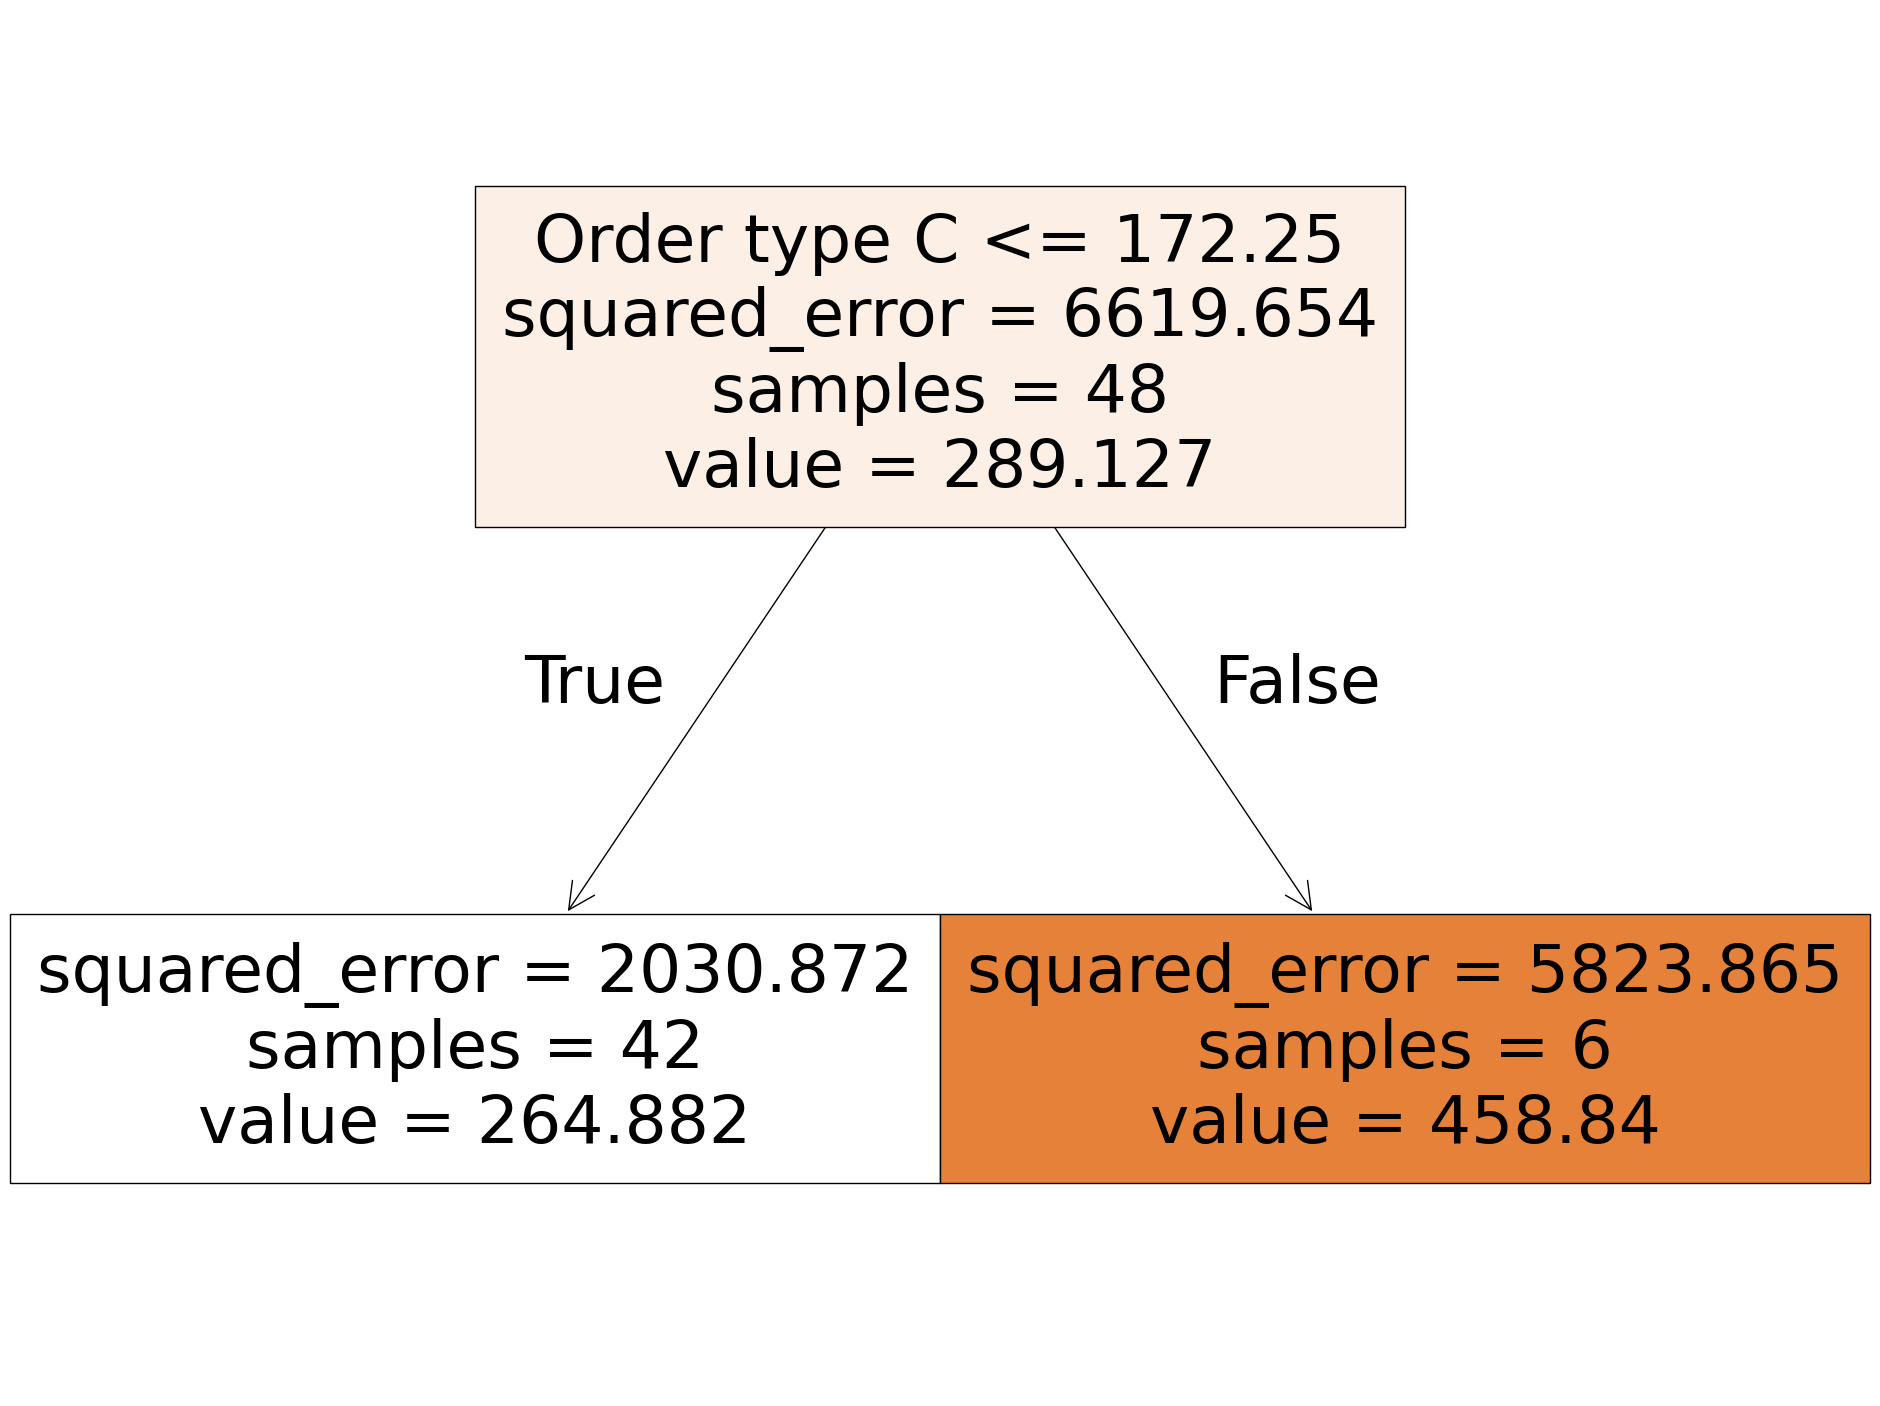

In [174]:
plt.figure(figsize=(24,18))

tree.plot_tree(
    tree_model,
    feature_names=X.columns,
    filled=True
)

plt.show()